In [20]:
#TODO: Learning Reinforcement #2 — Comparing Tip Percentages Across Days and Smoker Status

In [18]:
#I need learning reinforcement for the following : 
#How do you include gender and is_smoker in linear regression properly 
#Best plot to compare tip_pct across days and smoker status 
# prompt: create two learning reinforcements on these topics that will help me retain a better understanding of these topics.

In [2]:
# --- 1. Import libraries ---
import os
import sys
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Manually define the correct project root path based on your previous output
CORRECT_PROJECT_ROOT = "/home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one"

# Set CWD
try:
    os.chdir(CORRECT_PROJECT_ROOT)
    print(f"✅ CWD successfully set to: {os.getcwd()}")

    # Add to sys.path for module imports (src.helpers)
    if CORRECT_PROJECT_ROOT not in sys.path:
        sys.path.append(CORRECT_PROJECT_ROOT)
        print("✅ Added project root to sys.path.")

except FileNotFoundError:
    print("❌ CRITICAL ERROR: The manually defined project path does not exist.")
    sys.exit(1)

# --- 2. Load dataset saved previously above from seaborn's GitHub mirror ---
# NOTE: Path adjusted to be relative to the Project Root CWD
df = duckdb.query("""
    SELECT * FROM read_csv_auto('data/processed/tips_cleaned.csv')
""").df()

df.info

✅ CWD successfully set to: /home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one
✅ Added project root to sys.path.


<bound method DataFrame.info of      bill_total_usd  tip_usd  gender  is_smoker   day    time  party_size  \
0             16.99     1.01  Female      False   Sun  Dinner           2   
1             10.34     1.66    Male      False   Sun  Dinner           3   
2             21.01     3.50    Male      False   Sun  Dinner           3   
3             23.68     3.31    Male      False   Sun  Dinner           2   
4             24.59     3.61  Female      False   Sun  Dinner           4   
..              ...      ...     ...        ...   ...     ...         ...   
239           29.03     5.92    Male      False   Sat  Dinner           3   
240           27.18     2.00  Female       True   Sat  Dinner           2   
241           22.67     2.00    Male       True   Sat  Dinner           2   
242           17.82     1.75    Male      False   Sat  Dinner           2   
243           18.78     3.00  Female      False  Thur  Dinner           2   

      tip_pct  
0    0.059447  
1    0.1605

In [4]:
dummies.describe()

,is_smoker_Yes
count,244
unique,2
top,False
freq,151


In [10]:
dummies.is_smoker_Yes.unique()

array([False,  True])

In [19]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

df_work = df.copy()

#pd.get_dummies(..., drop_first=True)
#“Drop one dummy, keep your model sunny.”
#(You always drop one to avoid perfect multicollinearity.)

# If raw categoricals exist, normalize + encode them; otherwise proceed with what’s there
if "gender" in df_work.columns and "gender_Male" not in df_work.columns:
    g = df_work["gender"].astype(str).str.strip().str.lower().map({"male":"Male", "m":"Male", "female":"Female", "f":"Female"})
    df_work["gender"] = pd.Categorical(g, categories=["Female", "Male"])
    dummies = pd.get_dummies(df_work["gender"], prefix="gender", drop_first=True)
    df_work = pd.concat([df_work, dummies], axis=1)

if "is_smoker" in df_work.columns and "is_smoker_Yes" not in df_work.columns:
    s = df_work["is_smoker"].astype(str).str.strip().str.lower().map({"yes":"Yes", "y":"Yes", "true":"Yes", "1":"Yes",
                                                                      "no":"No",  "n":"No",  "false":"No",  "0":"No"})
    df_work["is_smoker"] = pd.Categorical(s, categories=["No", "Yes"])
    dummies = pd.get_dummies(df_work["is_smoker"], prefix="is_smoker", drop_first=True)
    df_work = pd.concat([df_work, dummies], axis=1)

X = df_work[["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]]
y = df_work["tip_usd"]

model = LinearRegression().fit(X, y)
pd.Series(model.coef_, index=X.columns)

bill_total_usd    0.094106
party_size        0.180280
gender_Male      -0.027263
is_smoker_Yes    -0.083711
dtype: float64

#### prompt: Am I correct in the following? 
Each **\$10** of additional bill increases the tip by 10 cents. Each additional party member added increases the tip by 18 cents. Males decrease the tip by about 3 cents per **\$10** spent, and smokers reduce the tip by 8 cents per **\$10** spent? 

Response: my understanding is incorrect by a factor error. The coefficients should be interpreted per **\$1** not per **\$10**

### 💡 Interpreting Linear Regression Coefficients (Tips Example)

| Variable | Coefficient | Interpretation (holding others constant) |
|-----------|--------------|-----------------------------------------|
| **bill_total_usd** | **0.094** | For each **\$1 increase** in the bill total, the tip increases by about **9.4¢** on average. |
| **party_size** | **0.180** | For each **additional person** in the party, the total tip increases by about **18¢**. |
| **gender_Male** | **–0.027** | Being male is associated with about **2.7¢ lower tips** than being female. |
| **is_smoker_Yes** | **–0.084** | Smokers are associated with about **8.4¢ lower tips** than non-smokers. |

---

#### 🧾 Optional: Expressed per \$10 increase in bill total
| Variable | Change per +\$10 bill |
|-----------|----------------------|
| **bill_total_usd** | +\$0.94 tip |
| **gender_Male** | –\$0.27 tip |
| **is_smoker_Yes** | –\$0.84 tip |

---

### 🧠 ELI5 Explanation
> Each coefficient tells how much the tip changes for a **1-unit change** in that feature, keeping everything else constant.  
> Here, 1 “unit” of `bill_total_usd` = \$1, 1 “unit” of `party_size` = one person,  
> and 1 “unit” of a dummy variable (e.g., `is_smoker_Yes`) means belonging to that group.  

So:
- Bigger bills → slightly bigger tips  
- Larger parties → slightly bigger tips  
- Male or smoker → slightly smaller tips  

✅ Your intuition was right — the only fix was to note that the coefficients are **per \$1**, not per $10.


### Learning Reinforcement #2 — Comparing Tip Percentages Across Days and Smoker Status

#### 🧩 Quick Recap

* For comparing **two categorical variables + one numeric**, the best choices are:

   * Boxplot: shows median + variability per group
   * Violin plot: adds distribution shape
   * FacetGrid: separates smokers/non-smokers visually

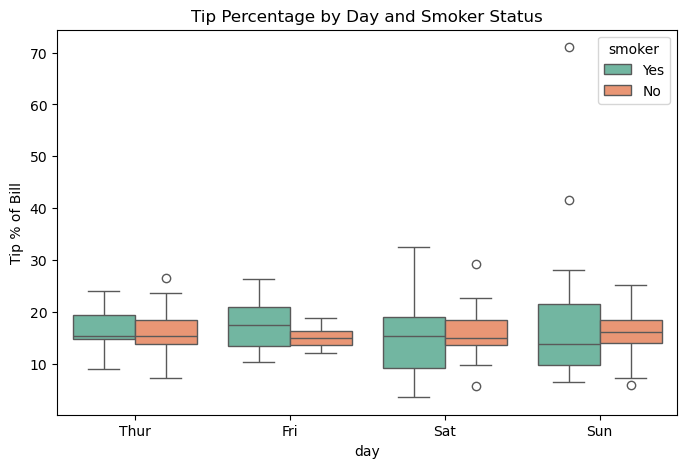

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")
df["tip_pct"] = df["tip"] / df["total_bill"] * 100

ax = plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="day", y="tip_pct", hue="smoker", palette="Set2")
plt.title("Tip Percentage by Day and Smoker Status")
plt.ylabel("Tip % of Bill")
plt.show()


In [25]:

# Log via your helper, if available
try:
    from src.helpers import save_and_log_plot
    save_and_log_plot(
        ax,
        "reports/figures/Tip_Percentage_by_Day_and_Smoker.png",
        df=df,
        chart_type="boxplot",
        library="seaborn",
        x="day",
        y="tip_pct",
        dataset_name="tips_encoded_or_clean",
        dataset_path="data/processed/tips_cleaned.csv",  # adjust if different
        notebook="notebooks/05A_QUIZ1.ipynb",
        notes="Tip Percentage by Day and Smoker Status.",
        timestamped=True
    )
except Exception as e:
    print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")


✅ Saved Matplotlib figure to: reports/figures/Tip_Percentage_by_Day_and_Smoker_2025-10-29_1215.png
📝 Logged metadata → reports/figures/Tip_Percentage_by_Day_and_Smoker_2025-10-29_1215.json
